In [1]:
import os
import shutil
from pathlib import Path
import random

In [2]:
# Ścieżka do oryginalnego Caltech101 (rozpakowanego)
caltech_root = Path(r"C:\\Users\\Kacper\\OneDrive\\Desktop\\SNN\\data\\Caltech101\\archive\\caltech-101")

# Docelowy folder dla podzbioru 5 klas
subset_root = Path(r"C:\\Users\\Kacper\\OneDrive\\Desktop\\SNN\\data\\caltech5_videos")
subset_root.mkdir(parents=True, exist_ok=True)

# 5 przykładowych klas
classes = ["accordion", "airplanes", "brain", "camera", "elephant"]


In [3]:
for cls in classes:
    (subset_root / cls).mkdir(exist_ok=True)

In [4]:
num_images_per_class = 10  # liczba obrazów do testu

for cls in classes:
    src_class_folder = caltech_root / cls
    dst_class_folder = subset_root / cls
    
    all_images = list(src_class_folder.glob("*.jpg"))
    selected_images = random.sample(all_images, min(num_images_per_class, len(all_images)))
    
    for i, img_path in enumerate(selected_images, 1):
        dst_file = dst_class_folder / f"{cls}_{i:03d}.jpg"
        shutil.copy(img_path, dst_file)

In [5]:
for cls in classes:
    print(cls, ":", len(list((subset_root / cls).glob("*.jpg"))), "obrazów")

accordion : 10 obrazów
airplanes : 10 obrazów
brain : 10 obrazów
camera : 10 obrazów
elephant : 10 obrazów


In [7]:
import sys
from pathlib import Path
import argparse

# Ścieżka do v2e
sys.path.append(r"C:\\Users\\Kacper\\v2e")

from v2ecore.v2e_args import v2e_args
from v2ecore.v2e_utils import *

# Tworzymy parser tak, jak robi to v2e.py
parser = argparse.ArgumentParser()
args = v2e_args(parser)

# Ustawienia konwersji
args.dvs240 = True
args.output_width = 240
args.output_height = 180
args.pos_thres = 0.2
args.neg_thres = 0.2
args.overwrite = True

# Ścieżki
input_folder = Path(r"C:\\Users\\Kacper\\OneDrive\\Desktop\\SNN\\data\\caltech5_videos")
output_root = Path(r"C:\\Users\\Kacper\\OneDrive\\Desktop\\SNN\\data\\Synthetic_DVS")
output_root.mkdir(parents=True, exist_ok=True)


In [8]:
import cv2

# Funkcja tworząca krótki AVI z pojedynczych obrazów
def create_video_from_images(image_paths, video_path, fps=25):
    # Pobierz wymiary z pierwszego obrazu
    img = cv2.imread(str(image_paths[0]))
    height, width, _ = img.shape

    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out = cv2.VideoWriter(str(video_path), fourcc, fps, (width, height))

    for img_path in image_paths:
        frame = cv2.imread(str(img_path))
        out.write(frame)
    out.release()

# Przykład dla jednej klasy
class_folder = input_folder / "accordion"
video_path = output_root / "accordion.avi"
image_files = sorted(class_folder.glob("*.jpg"))  # wszystkie obrazy w klasie
create_video_from_images(image_files[:1], video_path, fps=25)  # tu bierzemy np. 1 obraz

--- WYNIKI ---
Liczba zdarzeń: 157655
Czas trwania:   0.2980 s
Średnio:        529044 ev/s


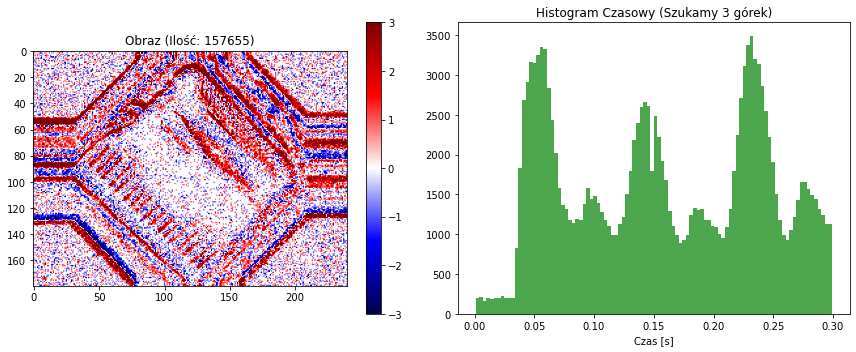

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

# Zmień na plik wygenerowany nowym skryptem!
TEST_FILE = r'C:\Users\Kacper\OneDrive\Desktop\SNN\data\Synthetic_DVS\accordion\accordion_004.h5'

WIDTH, HEIGHT = 240, 180

def check_results_robust():
    if not os.path.exists(TEST_FILE):
        print(f"Brak pliku: {TEST_FILE}")
        return

    with h5py.File(TEST_FILE, 'r') as f:
        events = f['events'][:] # [t, x, y, p]

    if len(events) == 0:
        print("Plik nie zawiera żadnych zdarzeń!")
        return

    # 1. Analiza Czasu
    t = events[:, 0]
    
    # Jeśli v2e zapisało w us, naprawiamy
    if t[-1] > 1000:
        t = t / 1e6
        events[:, 0] = t

    duration = t[-1] - t[0]
    count = len(events)
    
    print(f"--- WYNIKI ---")
    print(f"Liczba zdarzeń: {count}")
    print(f"Czas trwania:   {duration:.4f} s")
    if duration > 0:
        print(f"Średnio:        {count/duration:.0f} ev/s")
    else:
        print("BŁĄD: Czas trwania = 0s!")

    # 2. Wizualizacja Obrazu
    img = np.zeros((HEIGHT, WIDTH), dtype=float)
    x = events[:, 1].astype(int)
    y = events[:, 2].astype(int)
    p = events[:, 3]
    
    # Filtrowanie indeksów (Naprawa błędu IndexError)
    mask = (x >= 0) & (x < WIDTH) & (y >= 0) & (y < HEIGHT)
    x, y, p = x[mask], y[mask], p[mask]
    
    vals = np.where(p==1, 1, -1)
    np.add.at(img, (y, x), vals)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='seismic', vmin=-3, vmax=3)
    plt.title(f"Obraz (Ilość: {len(x)})")
    plt.colorbar()
    
    # 3. Wykres Czasu
    plt.subplot(1, 2, 2)
    plt.hist(t[mask], bins=100, color='green', alpha=0.7)
    plt.title("Histogram Czasowy (Szukamy 3 górek)")
    plt.xlabel("Czas [s]")
    
    plt.tight_layout()
    plt.show()

check_results_robust()

# NA Razie Najlepsze dane do uczenia

In [1]:
import os
import glob
import subprocess
import cv2
import numpy as np
import shutil
import h5py
from pathlib import Path
from tqdm.notebook import tqdm

# ================= KONFIGURACJA (FINAL TUNING) =================
INPUT_DIR = r"C:\\Users\\Kacper\\OneDrive\\Desktop\\SNN\\data\\Caltech101\\archive\\caltech-101"
OUTPUT_DIR = r"C:\\Users\\Kacper\\OneDrive\\Desktop\\SNN\\data\\Synthetic_DVS"
V2E_PATH = r"C:\\Users\\Kacper\\v2e"

OUT_WIDTH = 240
OUT_HEIGHT = 180

# Parametry (Zostawiamy te, które dały świetny histogram)
POS_TH = 0.235
NEG_TH = 0.235
SIGMA_TH = 0.04
REFRACTORY_PERIOD = 0.001
CUTOFF_HZ = 15
LEAK_RATE = 1.5
SHOT_NOISE = 2.0
NUM_FRAMES = 300
VIRTUAL_FPS = 1000 
# ===============================================================

def h5_to_ncaltech_bin_optimized(h5_path, bin_path):
    if not os.path.exists(h5_path): return
    with h5py.File(h5_path, 'r') as f:
        events = f['events'][:] 
    if len(events) == 0: return

    dt = np.dtype([('x', 'u1'), ('y', 'u1'), ('p', 'u1'), ('t', '>u4')])
    data = np.zeros(len(events), dtype=dt)
    data['t'] = (events[:, 0] * 1e6).astype(np.uint32)
    data['x'] = events[:, 1].astype(np.uint8)
    data['y'] = events[:, 2].astype(np.uint8)
    data['p'] = events[:, 3].astype(np.uint8)
    
    with open(bin_path, 'wb') as f:
        f.write(data.tobytes())

# === NOWA FUNKCJA 1: USUWANIE CZARNYCH ROGÓW ===
def crop_content(img):
    """
    Wycina użyteczną treść zdjęcia, usuwając czarne pasy/rogi wynikające z obrotu.
    """
    # Próg 15 pozwala ignorować "prawie czarne" szumy kompresji
    _, thresh = cv2.threshold(img, 15, 255, cv2.THRESH_BINARY)
    points = cv2.findNonZero(thresh)
    
    if points is not None:
        x, y, w, h = cv2.boundingRect(points)
        # Dodajemy minimalny margines do wewnątrz, żeby uciąć krawędź styku
        m = 2 
        h_img, w_img = img.shape
        x = max(0, x + m)
        y = max(0, y + m)
        w = max(1, w - 2*m)
        h = max(1, h - 2*m)
        return img[y:y+h, x:x+w]
    return img

# === NOWA FUNKCJA 2: LEPSZE SKALOWANIE I TŁO ===
def get_universal_frame(img, target_w, target_h, offset_x, offset_y):
    """
    Skaluje obraz metodą FIT (cały widoczny) i obsługuje krawędzie
    metodą REPLICATE (rozciąganie), aby uniknąć generowania sztucznych ramek.
    """
    h, w = img.shape[:2]
    
    # Skalowanie FIT z lekkim marginesem (95%), żeby obraz nie dotykał krawędzi
    safe_w = target_w * 0.95
    safe_h = target_h * 0.95
    scale = min(safe_w / w, safe_h / h)
    
    new_w = int(w * scale)
    new_h = int(h * scale)
    img_resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    # Obliczamy pozycję środkową + przesunięcie ruchu
    center_x = target_w / 2.0
    center_y = target_h / 2.0
    dest_x = center_x + offset_x
    dest_y = center_y + offset_y
    
    # Macierz transformacji (przesunięcie środka obrazka w odpowiednie miejsce)
    shift_x = dest_x - (new_w / 2.0)
    shift_y = dest_y - (new_h / 2.0)
    M = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
    
    # KLUCZOWA ZMIANA: BORDER_REPLICATE
    # Zamiast czerni, rozciągamy ostatni piksel obrazka w nieskończoność.
    # Dzięki temu na krawędziach nie ma kontrastu -> brak zdarzeń -> brak ramki.
    canvas = cv2.warpAffine(
        img_resized, 
        M, 
        (target_w, target_h), 
        borderMode=cv2.BORDER_REPLICATE
    )
    
    return canvas

def generate_frames(img_path, temp_folder, num_frames):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return False
    
    # 1. Najpierw usuwamy czarne rogi ze zdjęcia źródłowego
    img = crop_content(img)
    
    amplitude = 6.0 
    
    for i in range(num_frames):
        t = i / num_frames
        dx, dy = 0.0, 0.0
        
        if 0.1 < t < 0.3:
            val = np.sin((t - 0.1)/0.2 * np.pi) 
            dx, dy = amplitude * val, amplitude * 0.5 * val
        elif 0.4 < t < 0.6:
            val = np.sin((t - 0.4)/0.2 * np.pi)
            dx, dy = -amplitude * 0.8 * val, amplitude * 0.8 * val
        elif 0.7 < t < 0.9:
            val = np.sin((t - 0.7)/0.2 * np.pi)
            dx, dy = amplitude * 0.5 * val, -amplitude * val

        # 2. Używamy nowej funkcji generującej klatki
        frame = get_universal_frame(img, OUT_WIDTH, OUT_HEIGHT, dx, dy)
        cv2.imwrite(os.path.join(temp_folder, f"frame_{i:04d}.png"), frame)
    return True

def convert_dataset_polished():
    classes = [d for d in os.listdir(INPUT_DIR) if os.path.isdir(os.path.join(INPUT_DIR, d))]
    
    my_env = os.environ.copy()
    if "PYTHONPATH" in my_env:
        my_env["PYTHONPATH"] = V2E_PATH + os.pathsep + my_env["PYTHONPATH"]
    else:
        my_env["PYTHONPATH"] = V2E_PATH

    print(f"Start symulacji (Auto-Crop + Border Replicate)...")

    for cls in tqdm(classes):
        class_out_dir = os.path.join(OUTPUT_DIR, cls)
        os.makedirs(class_out_dir, exist_ok=True)
        image_paths = glob.glob(os.path.join(INPUT_DIR, cls, '*.[jJ][pP]*[gG]'))
        
        for img_path in tqdm(image_paths, desc=cls, leave=False):
            img_name = Path(img_path).stem
            out_h5 = os.path.join(class_out_dir, f"{img_name}.h5")
            out_bin = os.path.join(class_out_dir, f"{img_name}.bin")
            
            temp_frames_dir = os.path.join(class_out_dir, f"temp_{img_name}")
            if os.path.exists(temp_frames_dir): shutil.rmtree(temp_frames_dir)
            os.makedirs(temp_frames_dir)
            
            try:
                success = generate_frames(img_path, temp_frames_dir, NUM_FRAMES)
                if not success: continue
                
                cmd = [
                    "python", "-m", "v2e",
                    "--input", temp_frames_dir,
                    "--output_folder", class_out_dir,
                    "--output_width", str(OUT_WIDTH),
                    "--output_height", str(OUT_HEIGHT),
                    "--input_frame_rate", str(VIRTUAL_FPS),
                    "--disable_slomo",
                    "--pos_th", str(POS_TH),
                    "--neg_th", str(NEG_TH),
                    "--sigma_th", str(SIGMA_TH),
                    "--refractory_period", str(REFRACTORY_PERIOD),
                    "--cutoff_hz", str(CUTOFF_HZ),
                    "--leak_rate_hz", str(LEAK_RATE),
                    "--shot_noise_rate_hz", str(SHOT_NOISE),
                    "--no_preview",
                    "--overwrite",
                    "--unique_output_folder", "false",
                    "--dvs_h5", out_h5
                ]
                
                subprocess.run(cmd, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE, env=my_env)
                
                h5_to_ncaltech_bin_optimized(out_h5, out_bin)
                
            except subprocess.CalledProcessError as e:
                print(f"Error {img_name}: {e.stderr.decode('cp1250', errors='ignore')}")
            finally:
                if os.path.exists(temp_frames_dir): shutil.rmtree(temp_frames_dir)

    print("Zakończono.")

convert_dataset_polished()

Start symulacji (Auto-Crop + Border Replicate)...


  0%|          | 0/36 [00:00<?, ?it/s]

Motorbikes:   0%|          | 0/798 [00:00<?, ?it/s]

nautilus:   0%|          | 0/55 [00:00<?, ?it/s]

octopus:   0%|          | 0/35 [00:00<?, ?it/s]

...

wild_cat:   0%|          | 0/34 [00:00<?, ?it/s]

windsor_chair:   0%|          | 0/56 [00:00<?, ?it/s]

wrench:   0%|          | 0/39 [00:00<?, ?it/s]

yin_yang:   0%|          | 0/60 [00:00<?, ?it/s]

Zakończono.


Wczytywanie danych...

--- WYNIKI ---
[SYNTETYK] Ilość: 104624, Czas: 0.298s
[REALNY]   Ilość: 130747, Czas: 0.296s
STOSUNEK ILOŚCI ZDARZEŃ: 0.80 (Cel: ~1.0)
PODOBIEŃSTWO STRUKTURALNE (SSIM): 0.3857


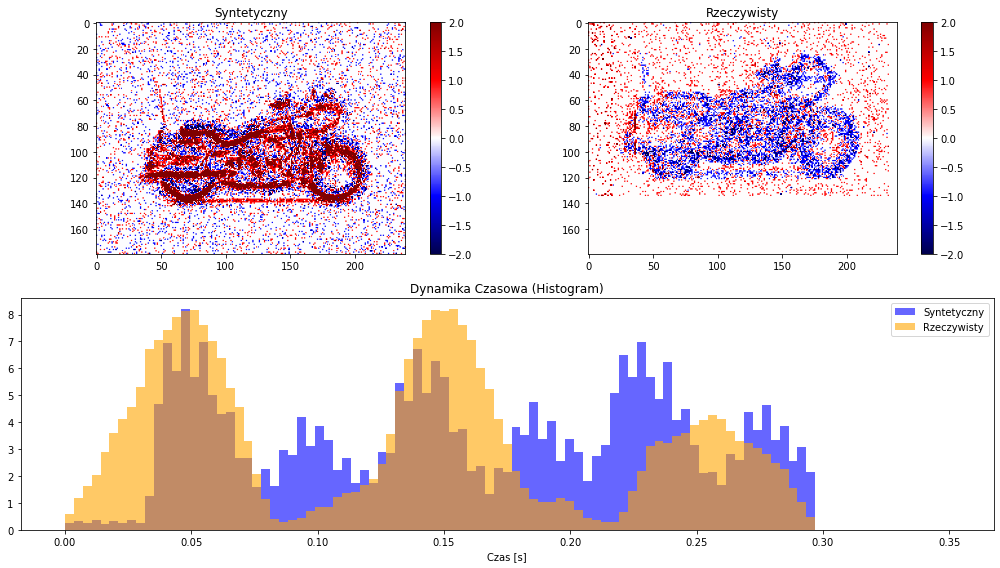

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import cv2
from skimage.metrics import structural_similarity as ssim

# ================= KONFIGURACJA =================
# Upewnij się, że ścieżki są poprawne!
SYNTH_FILE = r'C:\Users\Kacper\OneDrive\Desktop\SNN\data\Synthetic_DVS\Motorbikes\image_0009.h5'
REAL_FILE = r"C:\Users\Kacper\OneDrive\Desktop\SNN\data\N-Caltech101\NCALTECH101\Caltech101\Motorbikes\image_0009.bin"

WIDTH, HEIGHT = 240, 180
# ================================================

def load_h5(path):
    """Bezpieczne wczytywanie H5 z konwersją typów"""
    if not os.path.exists(path):
        print(f"Błąd: Nie znaleziono pliku {path}")
        return None
    
    try:
        with h5py.File(path, 'r') as f:
            # Wczytujemy dane surowe
            raw_events = f['events'][:] 
            
        # Konwersja na float64 (to naprawia Twój błąd!)
        # Tworzymy nową tablicę, zamiast modyfikować starą w miejscu
        events = raw_events.astype(np.float64)

        # Naprawa czasu (us -> s)
        if len(events) > 0:
            # Jeśli czas jest duży (mikrosekundy), dzielimy
            if events[-1, 0] > 1000: 
                events[:, 0] /= 1e6
            
            # Przesuwamy start do 0.0s
            events[:, 0] -= events[0, 0]
            
        return events
    except Exception as e:
        print(f"Krytyczny błąd wczytywania H5: {e}")
        return None

def load_bin(path):
    """Wczytywanie formatu N-Caltech .bin"""
    if not os.path.exists(path):
        print(f"Błąd: Nie znaleziono pliku {path}")
        return None

    try:
        with open(path, 'rb') as f:
            raw = np.fromfile(f, dtype=np.uint8)
        
        # Wyrównanie do 5 bajtów
        raw = raw[:len(raw)//5*5]
        
        x = raw[0::5]
        y = raw[1::5]
        p = (raw[2::5] >> 7) & 1
        
        # Dekodowanie czasu (Big Endian 4 bajty z maskowaniem)
        t_high = (raw[2::5] & 0x7f).astype(np.uint32)
        t_mid = raw[3::5].astype(np.uint32)
        t_low = raw[4::5].astype(np.uint32)
        ts_us = ((t_high << 16) | (t_mid << 8) | t_low)
        
        # Konwersja na float sekundy
        ts = ts_us.astype(np.float64) / 1e6
        
        # Złożenie w jedną macierz
        events = np.column_stack((ts, x, y, p))
        
        # Normalizacja czasu
        if len(events) > 0:
            events[:, 0] -= events[0, 0]
            
        return events
    except Exception as e:
        print(f"Błąd BIN: {e}")
        return None

def create_frame(events, shape):
    """Tworzy obraz 2D (zabezpieczony przed IndexError)"""
    img = np.zeros(shape, dtype=np.float32)
    if events is None or len(events) == 0: return img
    
    x = events[:, 1].astype(int)
    y = events[:, 2].astype(int)
    p = events[:, 3]
    
    # Kluczowe zabezpieczenie indeksów
    mask = (x >= 0) & (x < shape[1]) & (y >= 0) & (y < shape[0])
    
    x = x[mask]
    y = y[mask]
    p = p[mask]
    
    vals = np.where(p==1, 1, -1)
    np.add.at(img, (y, x), vals)
    
    return img

def compare_datasets():
    print("Wczytywanie danych...")
    ev_syn = load_h5(SYNTH_FILE)
    ev_real = load_bin(REAL_FILE)

    if ev_syn is None:
        print("Brak danych syntetycznych. Sprawdź ścieżkę.")
        return
    if ev_real is None:
        print("Brak danych rzeczywistych. Sprawdź ścieżkę.")
        # Kontynuujemy, żeby pokazać chociaż syntetyk
    
    # --- STATYSTYKI ---
    print("\n--- WYNIKI ---")
    count_syn = len(ev_syn)
    dur_syn = ev_syn[-1,0] - ev_syn[0,0] if count_syn > 0 else 0
    print(f"[SYNTETYK] Ilość: {count_syn}, Czas: {dur_syn:.3f}s")
    
    if ev_real is not None:
        count_real = len(ev_real)
        dur_real = ev_real[-1,0] - ev_real[0,0] if count_real > 0 else 0
        print(f"[REALNY]   Ilość: {count_real}, Czas: {dur_real:.3f}s")
        print(f"STOSUNEK ILOŚCI ZDARZEŃ: {count_syn/count_real:.2f} (Cel: ~1.0)")

        # Przycinamy syntetyk do czasu rzeczywistego dla wykresów
        max_t = min(dur_syn, dur_real)
        ev_syn_plot = ev_syn[ev_syn[:,0] <= max_t]
        ev_real_plot = ev_real[ev_real[:,0] <= max_t]
    else:
        ev_syn_plot = ev_syn
        ev_real_plot = None

    # --- WIZUALIZACJA ---
    plt.figure(figsize=(14, 8))
    
    # 1. Obrazy
    img_syn = create_frame(ev_syn, (HEIGHT, WIDTH))
    plt.subplot(2, 2, 1)
    plt.imshow(img_syn, cmap='seismic', vmin=-2, vmax=2)
    plt.title("Syntetyczny")
    plt.colorbar()

    if ev_real is not None:
        img_real = create_frame(ev_real, (HEIGHT, WIDTH))
        plt.subplot(2, 2, 2)
        plt.imshow(img_real, cmap='seismic', vmin=-2, vmax=2)
        plt.title("Rzeczywisty")
        plt.colorbar()
        
        # Oblicz SSIM (normalizacja 0-255)
        norm_syn = cv2.normalize(img_syn, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        norm_real = cv2.normalize(img_real, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        score, _ = ssim(norm_syn, norm_real, full=True)
        print(f"PODOBIEŃSTWO STRUKTURALNE (SSIM): {score:.4f}")

    # 2. Histogramy Czasowe
    plt.subplot(2, 1, 2)
    bins = np.linspace(0, 0.35, 100)
    
    plt.hist(ev_syn_plot[:, 0], bins=bins, alpha=0.6, label='Syntetyczny', color='blue', density=True)
    if ev_real_plot is not None:
        plt.hist(ev_real_plot[:, 0], bins=bins, alpha=0.6, label='Rzeczywisty', color='orange', density=True)
    
    plt.title("Dynamika Czasowa (Histogram)")
    plt.xlabel("Czas [s]")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

compare_datasets()